We are going to generate 40 rows of highly correlated 3D data (Imagine Height, Weight, and Shoe Size—they all move together).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA


In [2]:
# let's create that 3D dataset
np.random.seed(42)

# We create highly correlated data so PCA has a clear "best angle" to find
feature1 = np.random.normal(0, 10, 40)
feature2 = feature1 * 1.5 + np.random.normal(0, 4, 40)
feature3 = feature1 * -2.0 + np.random.normal(0, 3, 40)

# Combine into a DataFrame
df = pd.DataFrame({'F1': feature1, 'F2': feature2, 'F3': feature3})
print("Original 3D Data Shape:", df.shape)



Original 3D Data Shape: (40, 3)


## PCA without Scikit-learn

Let's perform PCA manually to understand the underlying mechanics. This involves standardizing the data, calculating the covariance matrix, finding eigenvalues and eigenvectors, and then projecting the data onto the chosen principal components.

In [6]:
# 1. Standardize the data (mean-center it)
df_scaled = df - df.mean()

# 2. Calculate the covariance matrix
cov_matrix = np.cov(df_scaled, rowvar=False)

# 3. Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvectors by eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# 4. Select principal components
# For 2D projection, take the first two principal components
pc_2d_manual = sorted_eigenvectors[:, :2]
data_2d_manual = df_scaled.dot(pc_2d_manual)

# For 1D projection, take the first principal component
pc_1d_manual = sorted_eigenvectors[:, :1]
data_1d_manual = df_scaled.dot(pc_1d_manual)

# 5. Calculate explained variance ratio manually
explained_variance_ratio_manual = sorted_eigenvalues / np.sum(sorted_eigenvalues)

var_2d_manual = np.sum(explained_variance_ratio_manual[:2]) * 100
var_1d_manual = np.sum(explained_variance_ratio_manual[:1]) * 100

print(f"Information kept in 2D (manual): {var_2d_manual:.2f}%")
print(f"Information kept in 1D (manual): {var_1d_manual:.2f}%")

Information kept in 2D (manual): 99.84%
Information kept in 1D (manual): 97.88%


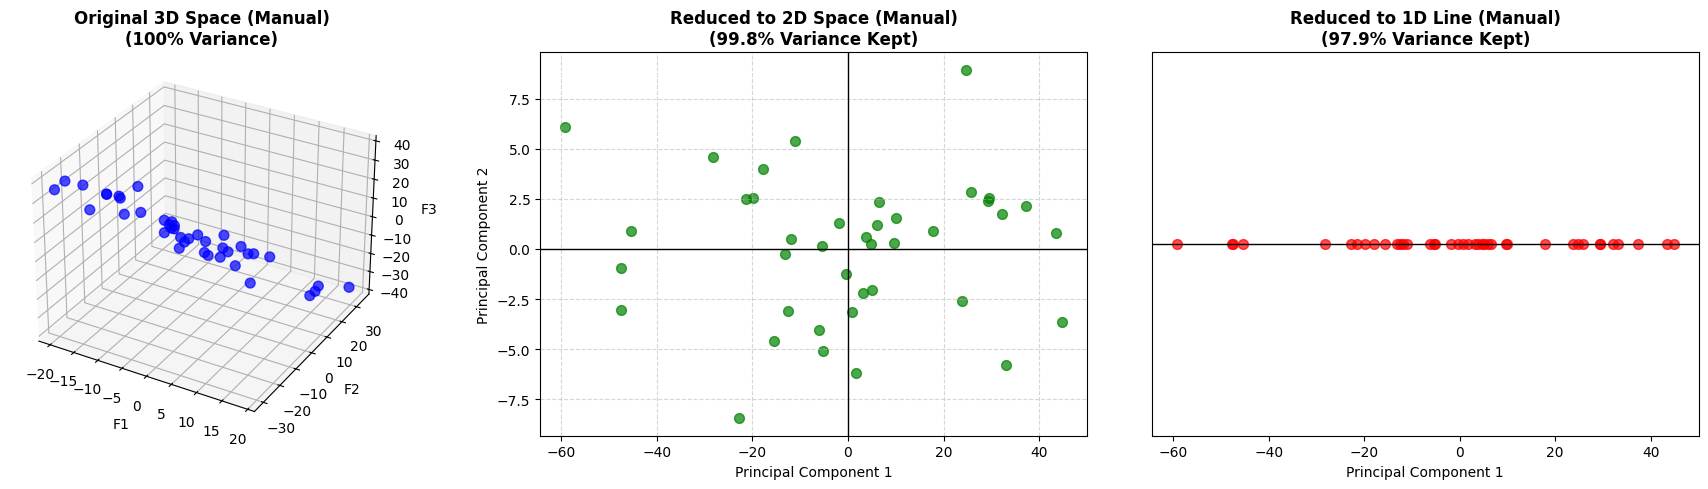

In [8]:
# Visualize the manual transformation
fig_manual = plt.figure(figsize=(18, 5))

# --- PLOT 1: Original 3D Data --- (Re-using original data for comparison)
ax1_manual = fig_manual.add_subplot(131, projection='3d')
ax1_manual.scatter(df['F1'], df['F2'], df['F3'], color='blue', s=50, alpha=0.7)
ax1_manual.set_title('Original 3D Space (Manual)\n(100% Variance)', fontweight='bold')
ax1_manual.set_xlabel('F1'); ax1_manual.set_ylabel('F2'); ax1_manual.set_zlabel('F3')

# --- PLOT 2: PCA 2D Projection (Manual) ---
ax2_manual = fig_manual.add_subplot(132)
ax2_manual.scatter(data_2d_manual.iloc[:, 0], data_2d_manual.iloc[:, 1], color='green', s=50, alpha=0.7)
ax2_manual.set_title(f'Reduced to 2D Space (Manual)\n({var_2d_manual:.1f}% Variance Kept)', fontweight='bold')
ax2_manual.set_xlabel('Principal Component 1')
ax2_manual.set_ylabel('Principal Component 2')
ax2_manual.grid(True, linestyle='--', alpha=0.5)
ax2_manual.axhline(0, color='black', linewidth=1); ax2_manual.axvline(0, color='black', linewidth=1)

# --- PLOT 3: PCA 1D Projection (Manual) ---
ax3_manual = fig_manual.add_subplot(133)
ax3_manual.scatter(data_1d_manual.iloc[:, 0], np.zeros(40), color='red', s=50, alpha=0.7)
ax3_manual.set_title(f'Reduced to 1D Line (Manual)\n({var_1d_manual:.1f}% Variance Kept)', fontweight='bold')
ax3_manual.set_xlabel('Principal Component 1')
ax3_manual.set_yticks([]) # Hide Y axis ticks because they don't exist anymore!
ax3_manual.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

# PCA with Scikit Learn

In [3]:
# Applying PCA
# We create two different PCA models for our two goals
pca_2d = PCA(n_components=2)
data_2d = pca_2d.fit_transform(df)

pca_1d = PCA(n_components=1)
data_1d = pca_1d.fit_transform(df)

In [4]:
# Check the variance
# explained_variance_ratio_ tells us how much "information" survived the crush
var_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
var_1d = np.sum(pca_1d.explained_variance_ratio_) * 100

print(f"Information kept in 2D: {var_2d:.2f}%")
print(f"Information kept in 1D: {var_1d:.2f}%")

Information kept in 2D: 99.84%
Information kept in 1D: 97.88%


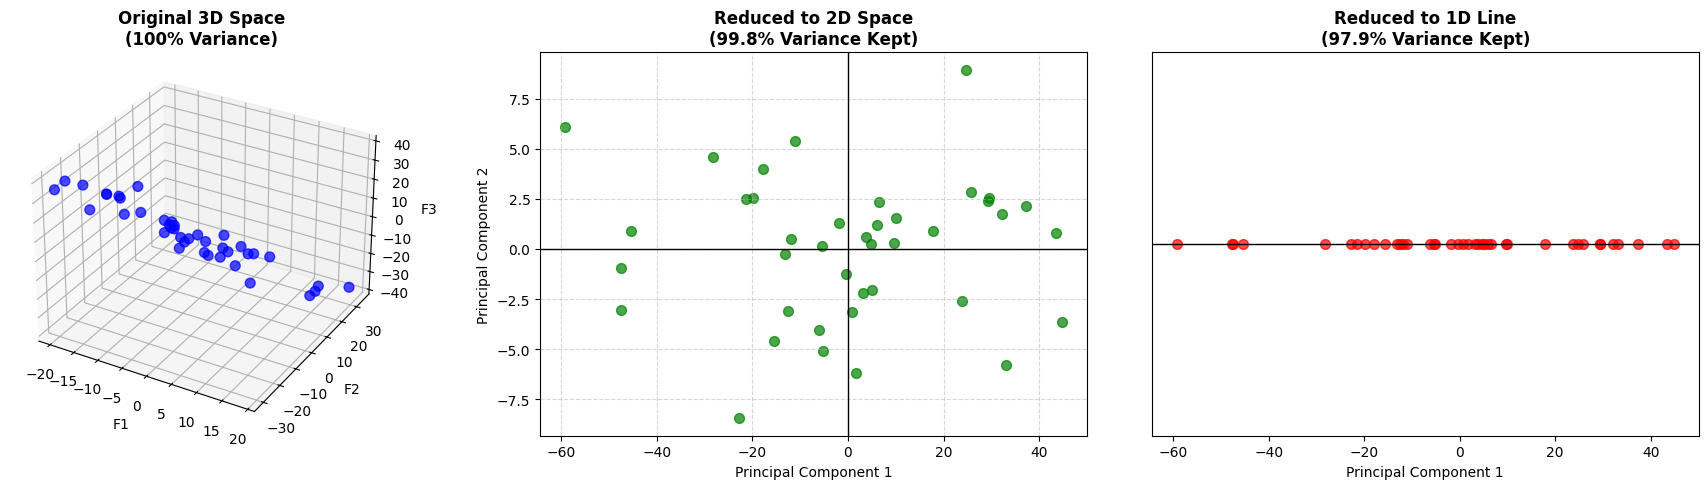

In [5]:
# Visualize the transformation
fig = plt.figure(figsize=(18, 5))

# --- PLOT 1: Original 3D Data ---
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(df['F1'], df['F2'], df['F3'], color='blue', s=50, alpha=0.7)
ax1.set_title('Original 3D Space\n(100% Variance)', fontweight='bold')
ax1.set_xlabel('F1'); ax1.set_ylabel('F2'); ax1.set_zlabel('F3')

# --- PLOT 2: PCA 2D Projection ---
ax2 = fig.add_subplot(132)
# We plot Principal Component 1 vs Principal Component 2
ax2.scatter(data_2d[:, 0], data_2d[:, 1], color='green', s=50, alpha=0.7)
ax2.set_title(f'Reduced to 2D Space\n({var_2d:.1f}% Variance Kept)', fontweight='bold')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=1); ax2.axvline(0, color='black', linewidth=1)

# --- PLOT 3: PCA 1D Projection ---
ax3 = fig.add_subplot(133)
# Y is forced to 0 because we only have 1 dimension (PC1)
ax3.scatter(data_1d[:, 0], np.zeros(40), color='red', s=50, alpha=0.7)
ax3.set_title(f'Reduced to 1D Line\n({var_1d:.1f}% Variance Kept)', fontweight='bold')
ax3.set_xlabel('Principal Component 1')
ax3.set_yticks([]) # Hide Y axis ticks because they don't exist anymore!
ax3.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()